In [2]:
pip install pandas numpy matplotlib seaborn scikit-learn

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

np.random.seed(42)
sns.set_style("whitegrid")

Scenario A — App Review Analysis

This scenario demonstrates selection bias (specifically voluntary feedback bias). App store reviews are typically written by users who had either extremely positive or extremely negative experiences, meaning they are not representative of the entire user base. As a result, the 4.3/5 average rating likely overestimates overall satisfaction and could lead the team to incorrectly reduce investment in customer support. A concrete fix would be to collect randomized in-app feedback surveys from a representative sample of users rather than relying only on public reviews.

Scenario B — Startup Success Study

This example illustrates survivorship bias. The study only includes startups that survived and are still operating, ignoring the many startups that failed. If many failed startups also pivoted early, pivoting may not actually be a success factor. A better approach would be to include both successful and failed startups in the dataset to determine whether pivoting truly correlates with higher survival rates.

Scenario C — Health Survey

This scenario reflects response bias combined with self-selection bias. Only 10% of recipients responded, and individuals who exercise more or are more health-conscious may be more likely to participate. This inflates estimates of average exercise and overall health compared to the broader population. A concrete fix would be to increase response rates using randomized follow-ups or incentives and apply weighting adjustments to better represent the full population.

Scenario D — Salary Benchmarking

This situation demonstrates coverage bias. The salary dataset mainly reflects users from large urban tech markets, meaning the salaries reported are not representative of workers in smaller towns. Using this data to set salaries in a small town could lead to unrealistic compensation expectations or budgeting errors. A fix would be to segment salary benchmarks by geographic region and cost-of-living differences or collect more representative data from smaller markets.

Population Summary
{'mean_age': np.float64(40.02052), 'mean_income': np.float64(60675.26928169441), 'mean_satisfaction': np.float64(5.424938181824401), 'region_proportions': region
Urban       0.59927
Suburban    0.25075
Rural       0.14998
Name: proportion, dtype: float64}


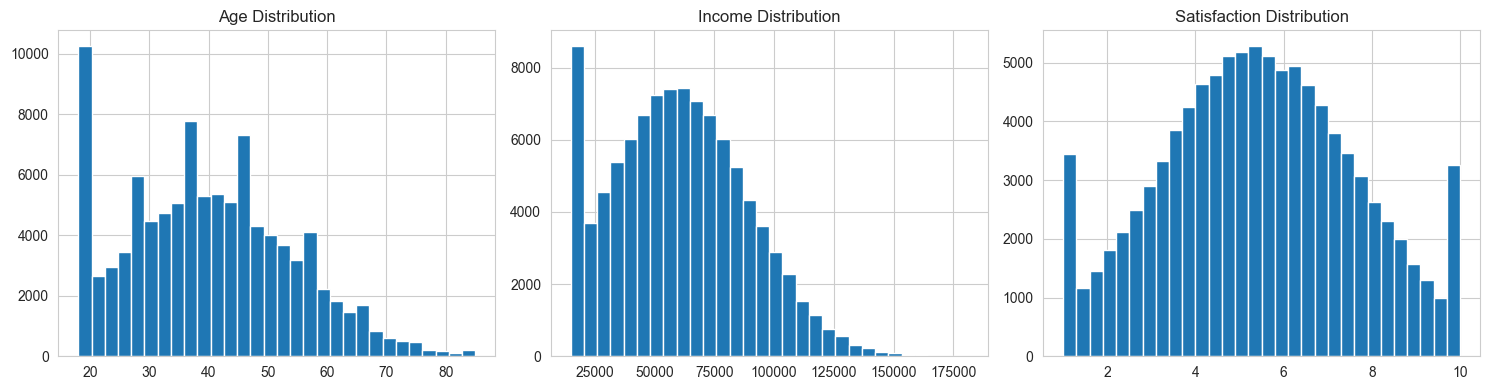

In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

np.random.seed(42)

N = 100000

# Age distribution
age = np.clip(np.random.normal(40, 15, N), 18, 85).astype(int)

# Income correlated with age
noise = np.random.normal(0, 20000, N)
income = 1500 * age + noise
income = np.clip(income, 15000, 250000)

# Satisfaction depends slightly on income
satisfaction_noise = np.random.normal(0, 2, N)
satisfaction = 3 + (income / 100000) * 4 + satisfaction_noise
satisfaction = np.clip(satisfaction, 1, 10)

# Region distribution
regions = np.random.choice(
    ["Urban", "Suburban", "Rural"],
    size=N,
    p=[0.60, 0.25, 0.15]
)

population = pd.DataFrame({
    "age": age,
    "income": income,
    "satisfaction": satisfaction,
    "region": regions
})

# True population parameters
population_summary = {
    "mean_age": population["age"].mean(),
    "mean_income": population["income"].mean(),
    "mean_satisfaction": population["satisfaction"].mean(),
    "region_proportions": population["region"].value_counts(normalize=True)
}

print("Population Summary")
print(population_summary)

fig, axes = plt.subplots(1, 3, figsize=(15,4))

axes[0].hist(population["age"], bins=30)
axes[0].set_title("Age Distribution")

axes[1].hist(population["income"], bins=30)
axes[1].set_title("Income Distribution")

axes[2].hist(population["satisfaction"], bins=30)
axes[2].set_title("Satisfaction Distribution")

plt.tight_layout()
plt.show()

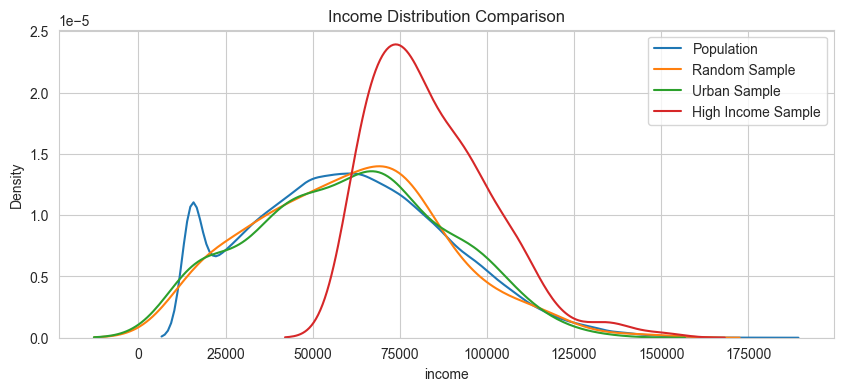

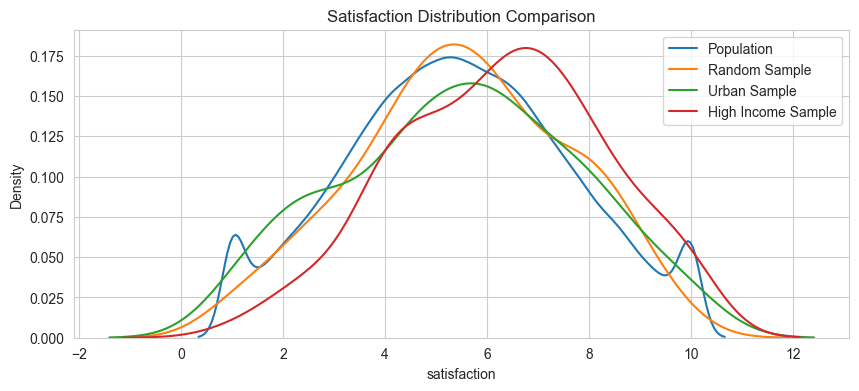

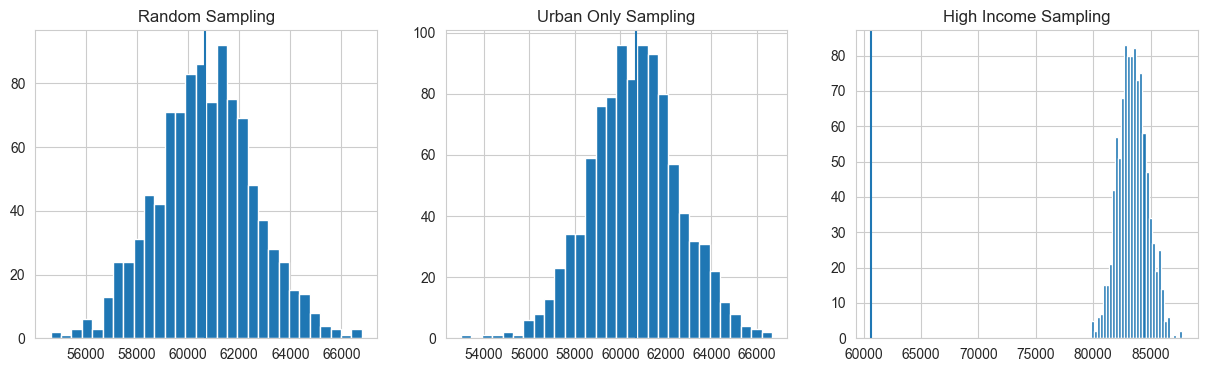

In [10]:
# True parameters
true_age = population["age"].mean()
true_income = population["income"].mean()
true_satisfaction = population["satisfaction"].mean()

# Simple random sample
sample_random = population.sample(200)

# Urban only
sample_urban = population[population["region"] == "Urban"].sample(200)

# High income filter
median_income = population["income"].median()
sample_high_income = population[population["income"] > median_income].sample(200)

def sample_stats(df):
    return pd.Series({
        "mean_age": df["age"].mean(),
        "mean_income": df["income"].mean(),
        "mean_satisfaction": df["satisfaction"].mean()
    })

comparison = pd.DataFrame({
    "Population": [true_age, true_income, true_satisfaction],
    "Random Sample": sample_stats(sample_random),
    "Urban Only": sample_stats(sample_urban),
    "High Income": sample_stats(sample_high_income)
},
index=["Age", "Income", "Satisfaction"])

comparison

import seaborn as sns

plt.figure(figsize=(10,4))

sns.kdeplot(population["income"], label="Population")
sns.kdeplot(sample_random["income"], label="Random Sample")
sns.kdeplot(sample_urban["income"], label="Urban Sample")
sns.kdeplot(sample_high_income["income"], label="High Income Sample")

plt.title("Income Distribution Comparison")
plt.legend()
plt.show()


plt.figure(figsize=(10,4))

sns.kdeplot(population["satisfaction"], label="Population")
sns.kdeplot(sample_random["satisfaction"], label="Random Sample")
sns.kdeplot(sample_urban["satisfaction"], label="Urban Sample")
sns.kdeplot(sample_high_income["satisfaction"], label="High Income Sample")

plt.title("Satisfaction Distribution Comparison")
plt.legend()
plt.show()

random_means = []
urban_means = []
high_income_means = []

for _ in range(1000):

    random_means.append(
        population.sample(200)["income"].mean()
    )

    urban_means.append(
        population[population.region=="Urban"].sample(200)["income"].mean()
    )

    high_income_means.append(
        population[population.income > median_income].sample(200)["income"].mean()
    )


fig, axes = plt.subplots(1,3, figsize=(15,4))

axes[0].hist(random_means, bins=30)
axes[0].axvline(true_income)
axes[0].set_title("Random Sampling")

axes[1].hist(urban_means, bins=30)
axes[1].axvline(true_income)
axes[1].set_title("Urban Only Sampling")

axes[2].hist(high_income_means, bins=30)
axes[2].axvline(true_income)
axes[2].set_title("High Income Sampling")

plt.show()

The simple random sampling strategy produces an unbiased estimate because its sampling distribution is centered around the true population mean income. This indicates that every individual had an equal probability of being selected, preserving the characteristics of the full population.

The Urban-only sample introduces bias because it excludes suburban and rural individuals. If urban populations tend to have higher incomes, the estimated mean income will systematically exceed the true population mean.

The High-income filter produces the most obvious bias, since it deliberately removes lower-income individuals from the sample. The sampling distribution will be heavily shifted upward relative to the true mean, clearly demonstrating systematic bias.